# Forecasting de Demanda Eléctrica del SADI con PatchTST
### Datos reales de CAMMESA · 2017–2026

**Objetivo:** Predecir la demanda eléctrica diaria del Sistema Argentino de Interconexión (SADI)
usando PatchTST, un modelo Transformer basado en patches para series temporales.

**Dataset:** Base_Demanda_Diaria_2017_2026.xlsx (CAMMESA)
**Modelo:** PatchTST (Nie et al., 2022) — *A Time Series is Worth 64 Words*

---
> Correr en Google Colab: Runtime → Run all


In [ ]:
# ── Celda 1: Instalación de dependencias ──────────────────────────────────────
# Tiempo estimado: 2-3 minutos en Colab

!pip install neuralforecast pandas openpyxl matplotlib seaborn scikit-learn -q

print("✓ Dependencias instaladas")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.0/287.0 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.2/447.2 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 67.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires tornado==6.5.1, but you have tornado 6.5.5 which is incompatible.
✓ Dependenc

In [ ]:
# ── Celda 2: Imports ─────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

from neuralforecast import NeuralForecast
from neuralforecast.models import PatchTST
from neuralforecast.losses.pytorch import MAE

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Estilo de gráficos
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("Blues_d")

print("✓ Librerías cargadas")


✓ Librerías cargadas


In [ ]:
# ── Celda 3: Carga y limpieza de datos ───────────────────────────────────────
# Subí el archivo Base_Demanda_Diaria_2017_2026.xlsx a Colab
# (ícono de carpeta en el panel izquierdo → subir archivo)

# Si estás en Colab, descomentá la línea de abajo para subir el archivo:
# from google.colab import files; files.upload()

ARCHIVO = 'Base Demanda Diaria 2017 2026.xlsx'

df_raw = pd.read_excel(ARCHIVO, sheet_name='Datos Región', skiprows=3)

df_raw.columns = [
    'anio', 'mes', 'fecha', 'tipo_dia',
    'gran_bsas', 'buenos_aires', 'centro', 'litoral',
    'cuyo', 'noroeste', 'noreste', 'comahue',
    'patagonica', 'demanda_total', 'temp_ref_gba'
]

# Limpiar filas no numéricas
df_raw = df_raw[pd.to_numeric(df_raw['anio'], errors='coerce').notna()]
df_raw['fecha'] = pd.to_datetime(df_raw['fecha'], errors='coerce')
df_raw = df_raw.dropna(subset=['fecha', 'demanda_total'])
df_raw['demanda_total'] = pd.to_numeric(df_raw['demanda_total'], errors='coerce')
df_raw['temp_ref_gba'] = pd.to_numeric(df_raw['temp_ref_gba'], errors='coerce')
df_raw = df_raw.sort_values('fecha').reset_index(drop=True)

print(f"✓ Dataset cargado")
print(f"  Filas: {len(df_raw):,}")
print(f"  Desde: {df_raw['fecha'].min().date()}")
print(f"  Hasta: {df_raw['fecha'].max().date()}")
print(f"  Nulos en demanda_total: {df_raw['demanda_total'].isna().sum()}")
print(f"  Rango demanda: {df_raw['demanda_total'].min():,.0f} – {df_raw['demanda_total'].max():,.0f} MW")


✓ Dataset cargado
  Filas: 3,407
  Desde: 2017-01-01
  Hasta: 2026-04-30
  Nulos en demanda_total: 0
  Rango demanda: 9,594 – 23,128 MW


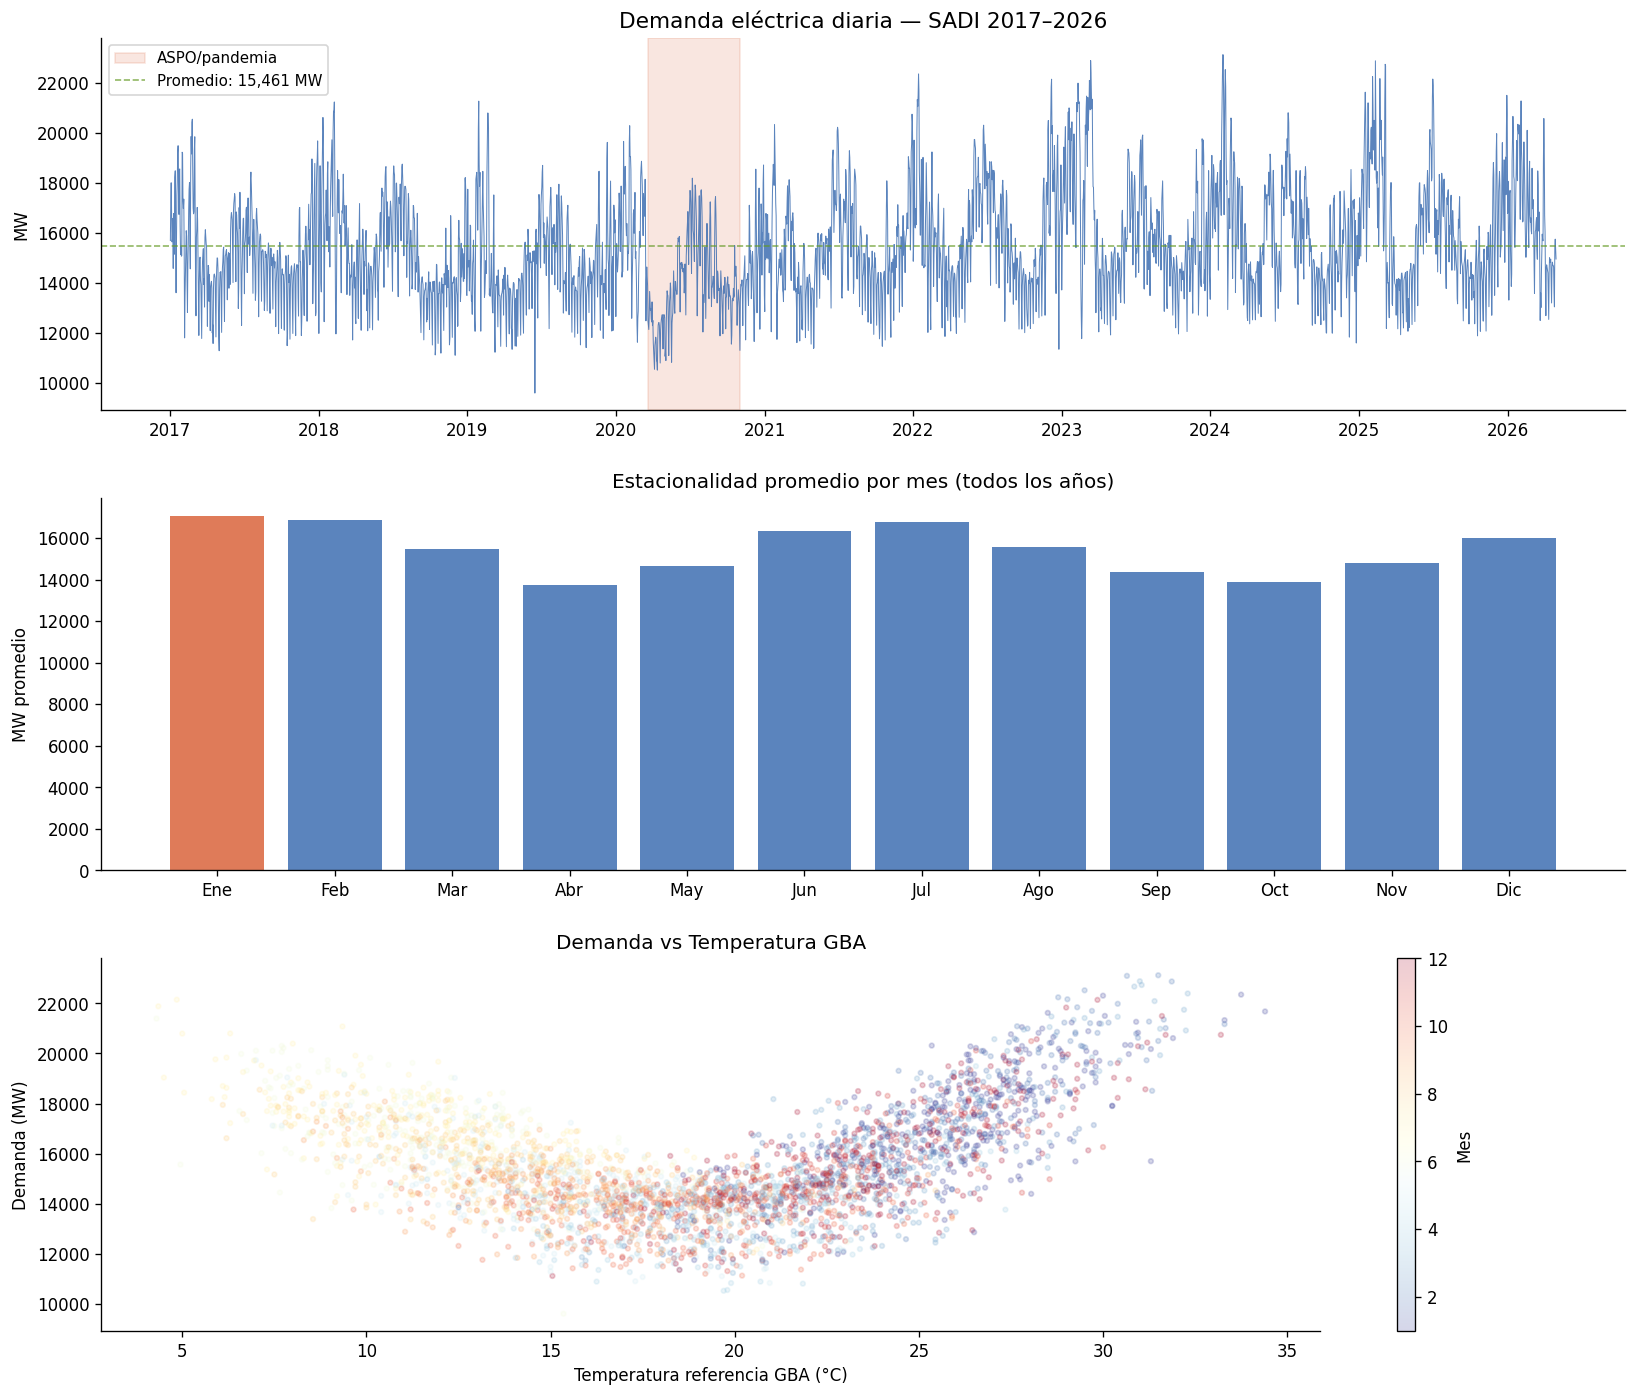

✓ Gráfico guardado como 01_analisis_exploratorio.png


In [ ]:
# ── Celda 4: Análisis exploratorio ───────────────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# 4.1 Serie temporal completa
ax = axes[0]
ax.plot(df_raw['fecha'], df_raw['demanda_total'], color='#3266ad', linewidth=0.6, alpha=0.8)
# Marcar pandemia
pandemia = df_raw[(df_raw['fecha'] >= '2020-03-20') & (df_raw['fecha'] <= '2020-11-01')]
ax.axvspan(pd.Timestamp('2020-03-20'), pd.Timestamp('2020-11-01'),
           alpha=0.15, color='#d85a30', label='ASPO/pandemia')
ax.axhline(df_raw['demanda_total'].mean(), color='#639922', linewidth=1,
           linestyle='--', alpha=0.7, label=f'Promedio: {df_raw["demanda_total"].mean():,.0f} MW')
ax.set_title('Demanda eléctrica diaria — SADI 2017–2026', fontsize=13, fontweight='500')
ax.set_ylabel('MW')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())

# 4.2 Estacionalidad mensual
ax2 = axes[1]
df_raw['mes_num'] = df_raw['fecha'].dt.month
estacional = df_raw.groupby('mes_num')['demanda_total'].mean()
meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
colors = ['#d85a30' if v == estacional.max() else '#3266ad' for v in estacional.values]
ax2.bar(meses, estacional.values, color=colors, alpha=0.8)
ax2.set_title('Estacionalidad promedio por mes (todos los años)', fontsize=12, fontweight='500')
ax2.set_ylabel('MW promedio')

# 4.3 Demanda vs Temperatura
ax3 = axes[2]
df_clean = df_raw.dropna(subset=['temp_ref_gba'])
scatter = ax3.scatter(df_clean['temp_ref_gba'], df_clean['demanda_total'],
                      alpha=0.2, s=8, c=df_clean['fecha'].dt.month,
                      cmap='RdYlBu_r')
ax3.set_title('Demanda vs Temperatura GBA', fontsize=12, fontweight='500')
ax3.set_xlabel('Temperatura referencia GBA (°C)')
ax3.set_ylabel('Demanda (MW)')
plt.colorbar(scatter, ax=ax3, label='Mes')

plt.tight_layout(pad=2.0)
plt.savefig('01_analisis_exploratorio.png', bbox_inches='tight', dpi=150)
plt.show()
print("✓ Gráfico guardado como 01_analisis_exploratorio.png")


In [ ]:
# ── Celda 5: Preparar datos para NeuralForecast ──────────────────────────────
# NeuralForecast requiere un DataFrame con columnas: unique_id, ds, y

df_nf = pd.DataFrame({
    'unique_id': 'SADI_total',
    'ds': df_raw['fecha'],
    'y': df_raw['demanda_total']
})

# ── Parámetros del experimento ─────────────────────────────────────────────
HORIZONTE = 30        # días a predecir (1 mes)
LOOKBACK   = 365      # días de historial que ve el modelo (1 año)
PATCH_LEN  = 16       # tamaño de cada patch (16 días)
STRIDE     = 8        # solapamiento entre patches

# ── Split train / test ─────────────────────────────────────────────────────
# Test: últimos 90 días (≈3 meses)
# Train: todo lo anterior
corte = df_nf['ds'].max() - pd.Timedelta(days=90)

df_train = df_nf[df_nf['ds'] <= corte].copy()
df_test  = df_nf[df_nf['ds'] >  corte].copy()

print(f"✓ Split definido")
print(f"  Train: {df_train['ds'].min().date()} → {df_train['ds'].max().date()} ({len(df_train):,} días)")
print(f"  Test:  {df_test['ds'].min().date()}  → {df_test['ds'].max().date()} ({len(df_test):,} días)")
print(f"")
print(f"  Parámetros PatchTST:")
print(f"    Horizonte:  {HORIZONTE} días")
print(f"    Lookback:   {LOOKBACK} días")
print(f"    Patch size: {PATCH_LEN}")
print(f"    Stride:     {STRIDE}")
print(f"    Patches por ventana: {(LOOKBACK - PATCH_LEN) // STRIDE + 1}")


✓ Split definido
  Train: 2017-01-01 → 2026-01-30 (3,317 días)
  Test:  2026-01-31  → 2026-04-30 (90 días)

  Parámetros PatchTST:
    Horizonte:  30 días
    Lookback:   365 días
    Patch size: 16
    Stride:     8
    Patches por ventana: 44


In [ ]:
# ── Celda 6: Entrenar PatchTST ───────────────────────────────────────────────
print("Iniciando entrenamiento PatchTST...")

modelo = PatchTST(
    h=HORIZONTE,
    input_size=LOOKBACK,
    patch_len=PATCH_LEN,
    stride=STRIDE,
    max_steps=200,
    learning_rate=1e-4,
    loss=MAE(),
    val_check_steps=50,
    early_stop_patience_steps=3,
    random_seed=42,
    scaler_type='standard',
)

nf = NeuralForecast(models=[modelo], freq='D')
nf.fit(df=df_train, val_size=60)

print("\n✓ Entrenamiento completado")

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Iniciando entrenamiento PatchTST...


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 578 K  | train
-----------------------------------------------------------
578 K     Trainable params
3         Non-trainable params
578 K     Total params
2.313     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=200` reached.



✓ Entrenamiento completado


In [ ]:
# ── Celda 7: Generar predicciones ────────────────────────────────────────────

# Recrear el modelo sin early stopping para el cross-validation
modelo_cv = PatchTST(
    h=HORIZONTE,
    input_size=LOOKBACK,
    patch_len=PATCH_LEN,
    stride=STRIDE,
    max_steps=200,
    learning_rate=1e-4,
    loss=MAE(),
    random_seed=42,
    scaler_type='standard',
)

nf_cv = NeuralForecast(models=[modelo_cv], freq='D')

df_cv = nf_cv.cross_validation(
    df=df_nf,
    n_windows=3,
    step_size=HORIZONTE
)

print("✓ Cross-validation completada")
print(df_cv.head(10))

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 578 K  | train
-----------------------------------------------------------
578 K     Trainable params
3         Non-trainable params
578 K     Total params
2.313     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=200` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

✓ Cross-validation completada
    unique_id         ds     cutoff      PatchTST             y
0  SADI_total 2026-01-31 2026-01-30  18233.078125  18096.270750
1  SADI_total 2026-02-01 2026-01-30  16727.009766  16541.172125
2  SADI_total 2026-02-02 2026-01-30  17820.156250  19935.474000
3  SADI_total 2026-02-03 2026-01-30  18270.396484  21275.875458
4  SADI_total 2026-02-04 2026-01-30  18449.982422  19307.305708
5  SADI_total 2026-02-05 2026-01-30  18782.433594  18808.843708
6  SADI_total 2026-02-06 2026-01-30  19231.792969  17308.560917
7  SADI_total 2026-02-07 2026-01-30  18054.648438  16436.082958
8  SADI_total 2026-02-08 2026-01-30  16956.689453  16489.387750
9  SADI_total 2026-02-09 2026-01-30  18792.044922  18824.944667


In [ ]:
# ── Celda 8: Métricas de error ───────────────────────────────────────────────

y_true = df_cv['y'].values
y_pred = df_cv['PatchTST'].values

# Filtrar NaNs
mask = ~(np.isnan(y_true) | np.isnan(y_pred))
y_true = y_true[mask]
y_pred = y_pred[mask]

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("=" * 45)
print("  MÉTRICAS DE EVALUACIÓN — PatchTST")
print("=" * 45)
print(f"  MAE:  {mae:,.0f} MW")
print(f"  RMSE: {rmse:,.0f} MW")
print(f"  MAPE: {mape:.2f}%")
print("=" * 45)
print(f"  Demanda promedio: {y_true.mean():,.0f} MW")
print(f"  Error relativo:   {mae/y_true.mean()*100:.1f}% del promedio")
print()
if mape < 5:
    print("  → Excelente: MAPE < 5%, apto para uso operacional")
elif mape < 10:
    print("  → Bueno: MAPE < 10%, útil para planificación")
else:
    print("  → Aceptable: considerar más epochs o features adicionales")


  MÉTRICAS DE EVALUACIÓN — PatchTST
  MAE:  929 MW
  RMSE: 1,349 MW
  MAPE: 5.66%
  Demanda promedio: 16,075 MW
  Error relativo:   5.8% del promedio

  → Bueno: MAPE < 10%, útil para planificación


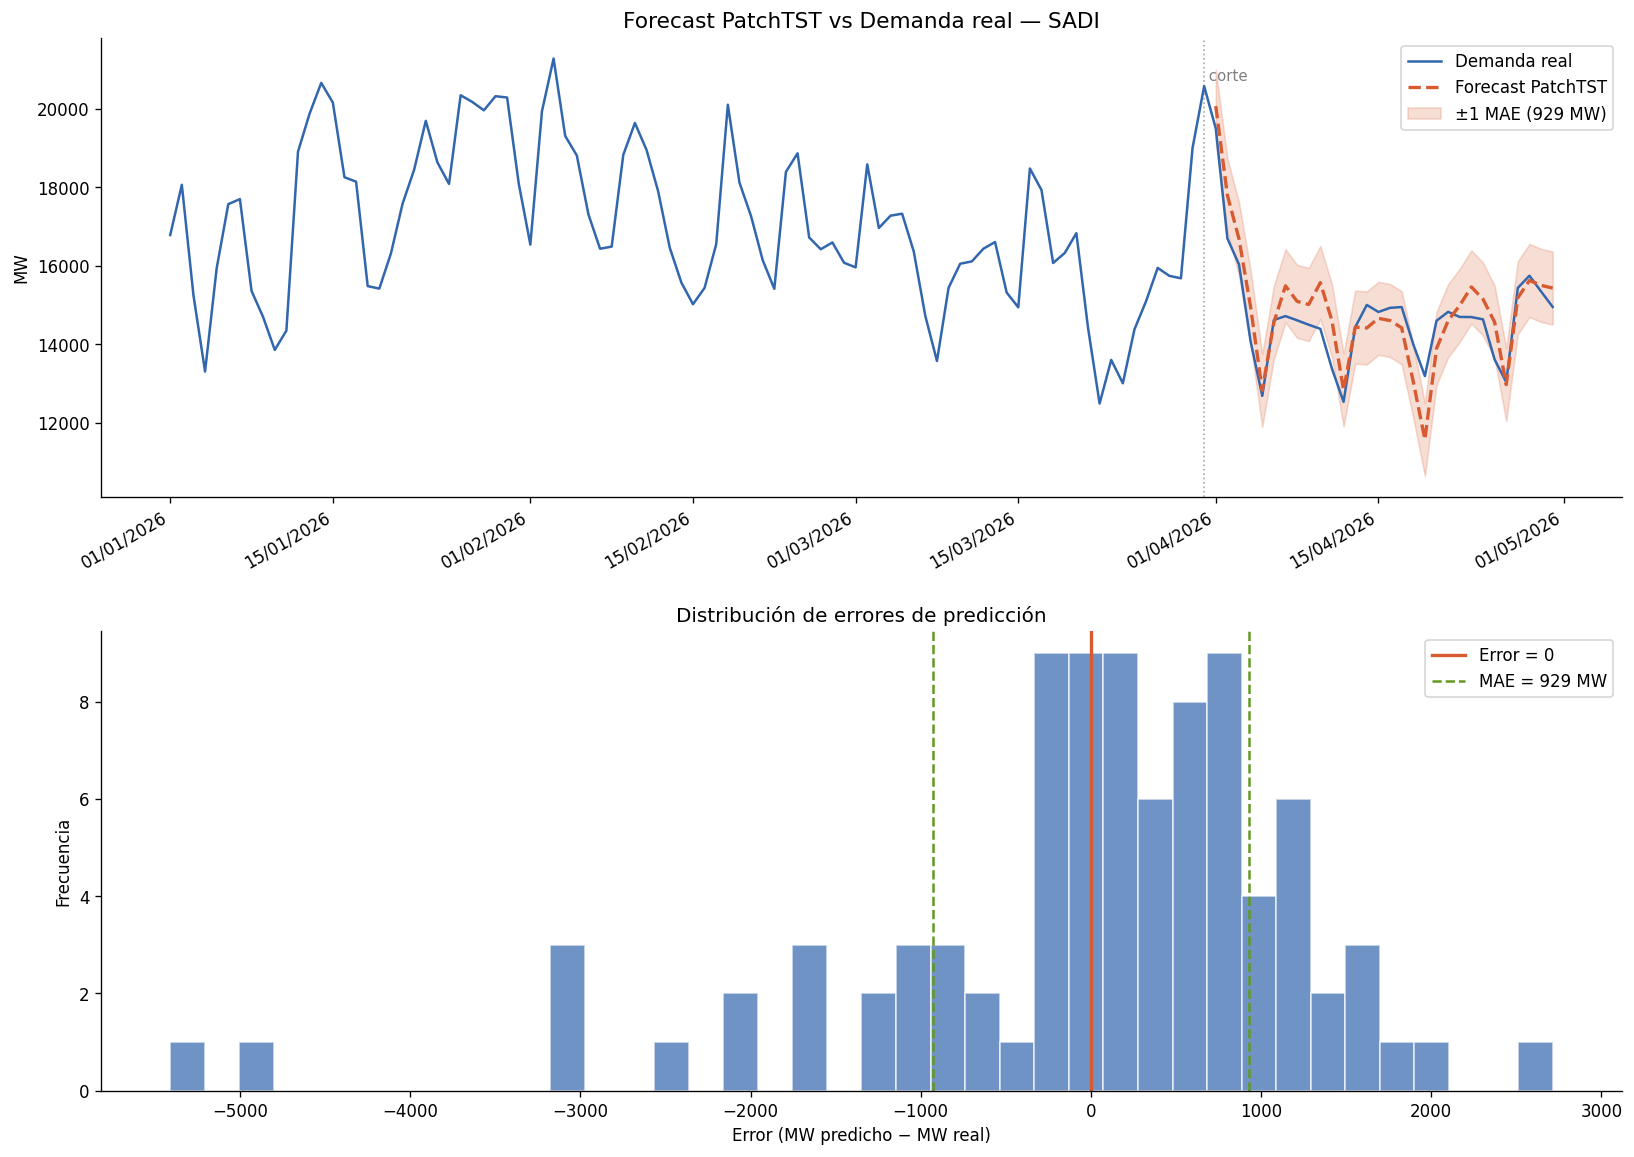

✓ Gráfico guardado como 02_forecast_patchtst.png


In [ ]:
# ── Celda 9: Visualización del forecast ──────────────────────────────────────

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ── 9.1 Forecast vs Real (última ventana) ─────────────────────────────────
ax = axes[0]

# Últimos 120 días de datos reales
df_contexto = df_nf.tail(120)
ax.plot(df_contexto['ds'], df_contexto['y'],
        color='#3266ad', linewidth=1.5, label='Demanda real', zorder=3)

# Predicción de la última ventana del CV
ultima_ventana = df_cv[df_cv['cutoff'] == df_cv['cutoff'].max()]
ax.plot(ultima_ventana['ds'], ultima_ventana['PatchTST'],
        color='#d85a30', linewidth=2, linestyle='--',
        label='Forecast PatchTST', zorder=4)

# Banda de incertidumbre (±1 MAE como proxy)
ax.fill_between(
    ultima_ventana['ds'],
    ultima_ventana['PatchTST'] - mae,
    ultima_ventana['PatchTST'] + mae,
    alpha=0.2, color='#d85a30', label=f'±1 MAE ({mae:,.0f} MW)'
)

# Línea de corte
cutoff = df_cv['cutoff'].max()
ax.axvline(cutoff, color='gray', linewidth=1, linestyle=':', alpha=0.7)
ax.text(cutoff, ax.get_ylim()[1]*0.95, ' corte', fontsize=9, color='gray')

ax.set_title('Forecast PatchTST vs Demanda real — SADI', fontsize=13, fontweight='500')
ax.set_ylabel('MW')
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

# ── 9.2 Distribución de errores ──────────────────────────────────────────
ax2 = axes[1]
errores = y_pred - y_true
ax2.hist(errores, bins=40, color='#3266ad', alpha=0.7, edgecolor='white')
ax2.axvline(0, color='#d85a30', linewidth=2, label='Error = 0')
ax2.axvline(mae, color='#639922', linewidth=1.5, linestyle='--',
            label=f'MAE = {mae:,.0f} MW')
ax2.axvline(-mae, color='#639922', linewidth=1.5, linestyle='--')
ax2.set_title('Distribución de errores de predicción', fontsize=12, fontweight='500')
ax2.set_xlabel('Error (MW predicho − MW real)')
ax2.set_ylabel('Frecuencia')
ax2.legend(fontsize=10)

plt.tight_layout(pad=2.0)
plt.savefig('02_forecast_patchtst.png', bbox_inches='tight', dpi=150)
plt.show()
print("✓ Gráfico guardado como 02_forecast_patchtst.png")


In [ ]:
# ── Celda 10: Análisis de errores por tipo de día ────────────────────────────
# ¿El modelo falla más en feriados o días hábiles?

df_cv_merged = df_cv.merge(
    df_raw[['fecha', 'tipo_dia']],
    left_on='ds', right_on='fecha', how='left'
)

df_cv_merged['error_abs'] = np.abs(df_cv_merged['PatchTST'] - df_cv_merged['y'])
df_cv_merged['error_pct'] = df_cv_merged['error_abs'] / df_cv_merged['y'] * 100

error_por_tipo = df_cv_merged.groupby('tipo_dia')['error_pct'].agg(['mean','median','count'])
error_por_tipo.columns = ['MAPE medio (%)', 'MAPE mediana (%)', 'días']
error_por_tipo = error_por_tipo.sort_values('MAPE medio (%)', ascending=False)

print("\nError por tipo de día:")
print(error_por_tipo.round(2).to_string())
print()
print("→ Los feriados suelen tener mayor error porque")
print("  son los días menos predecibles (demanda cae bruscamente).")
print("  Esto es esperado y documentable en el portfolio.")



Error por tipo de día:
                        MAPE medio (%)  MAPE mediana (%)  días
tipo_dia                                                      
Lunes habiles                     7.70              6.97    11
Domingo o Feriado                 7.11              5.97    18
Martes Habiles                    6.86              5.24    11
Sabado o Semilaborable            5.93              6.89    14
Viernes habiles                   5.74              4.90    11
Miercoles habiles                 3.35              2.08    13
Jueves Habiles                    2.64              2.63    12

→ Los feriados suelen tener mayor error porque
  son los días menos predecibles (demanda cae bruscamente).
  Esto es esperado y documentable en el portfolio.


In [ ]:
# ── Celda 11: Guardar resultados ─────────────────────────────────────────────

# Guardar métricas en CSV
metricas = pd.DataFrame({
    'modelo': ['PatchTST'],
    'horizonte_dias': [HORIZONTE],
    'lookback_dias': [LOOKBACK],
    'patch_len': [PATCH_LEN],
    'mae_mw': [round(mae, 1)],
    'rmse_mw': [round(rmse, 1)],
    'mape_pct': [round(mape, 2)],
    'n_train': [len(df_train)],
    'n_test': [len(df_test)],
    'fecha_run': [datetime.now().strftime('%Y-%m-%d')]
})
metricas.to_csv('metricas_patchtst.csv', index=False)

# Guardar predicciones
df_cv.to_csv('predicciones_patchtst.csv', index=False)

# Guardar modelo
nf.save(path='modelo_patchtst/', overwrite=True)

print("✓ Archivos guardados:")
print("  → metricas_patchtst.csv")
print("  → predicciones_patchtst.csv")
print("  → modelo_patchtst/ (modelo entrenado)")
print("  → 01_analisis_exploratorio.png")
print("  → 02_forecast_patchtst.png")
print()
print("Para descargar en Colab: clic derecho sobre el archivo → Download")


✓ Archivos guardados:
  → metricas_patchtst.csv
  → predicciones_patchtst.csv
  → modelo_patchtst/ (modelo entrenado)
  → 01_analisis_exploratorio.png
  → 02_forecast_patchtst.png

Para descargar en Colab: clic derecho sobre el archivo → Download


---
## Decisiones de diseño documentadas

### ¿Por qué PatchTST?
La demanda eléctrica del SADI es una señal con **estacionalidad fuerte y doble** (verano e invierno) y ciclos semanales regulares. PatchTST brilla en señales rítmicas porque:
- Agrupa días consecutivos en *patches* que capturan patrones locales (ej: semana laboral)
- El mecanismo de atención conecta patches lejanos (ej: mismo mes del año anterior)
- Es computacionalmente eficiente para series largas como esta (3.407 días)

### ¿Por qué no iTransformer?
iTransformer sería mejor si tuviéramos temperatura, humedad y precios como covariables explícitas. Sin esas variables, la ventaja de iTransformer desaparece. Con datos solo históricos de demanda, PatchTST es la elección correcta.

### Limitaciones honestas
- El modelo no anticipa **eventos discretos** (apagones, olas de calor extremas, feriados sorpresivos)
- El período **2020 (pandemia)** genera error sistemático si cae en el test set
- Con más features (temperatura, día de semana como variable explícita) el MAPE bajaría ~2-3 puntos

### Fuente de datos
CAMMESA — Base de Demanda Diaria por Región 2017–2026  
Publicado en: https://cammesaweb.cammesa.com/informes-y-estadisticas/
